In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('2019_nC0v_20200121_20200126 - SUMMARY.csv')

df.head()

,Province/State,Country,Date last updated,Confirmed,Suspected,Recovered,Deaths
0,Shanghai,Mainland China,1/21/2020,9.0,10.0,NaN,NaN
1,Yunnan,Mainland China,1/21/2020,1.0,NaN,NaN,NaN
2,Beijing,Mainland China,1/21/2020,10.0,NaN,NaN,NaN
3,Taiwan,Mainland China,1/21/2020,1.0,NaN,NaN,NaN
4,Jilin,Mainland China,1/21/2020,NaN,1.0,NaN,NaN


In [3]:
df.isnull().sum()


Province/State        64
Country                0
Date last updated      0
Confirmed             29
Suspected            280
Recovered            332
Deaths               344
dtype: int64

In [4]:
df['Province/State'] = df['Province/State'].fillna("National")

df

,Province/State,Country,Date last updated,Confirmed,Suspected,Recovered,Deaths
0,Shanghai,Mainland China,1/21/2020,9.0,10.0,NaN,NaN
1,Yunnan,Mainland China,1/21/2020,1.0,NaN,NaN,NaN
2,Beijing,Mainland China,1/21/2020,10.0,NaN,NaN,NaN
3,Taiwan,Mainland China,1/21/2020,1.0,NaN,NaN,NaN
4,Jilin,Mainland China,1/21/2020,NaN,1.0,NaN,NaN
...,...,...,...,...,...,...,...
363,National,France,1/26/2020 11:00 AM,3.0,NaN,NaN,NaN
364,National,Australia,1/26/2020 11:00 AM,4.0,NaN,NaN,NaN
365,National,Nepal,1/26/2020 11:00 AM,1.0,NaN,NaN,NaN
366,National,Malaysia,1/26/2020 11:00 AM,4.0,NaN,NaN,NaN


In [5]:
df['Confirmed'] = df['Confirmed'].fillna(0)

df

,Province/State,Country,Date last updated,Confirmed,Suspected,Recovered,Deaths
0,Shanghai,Mainland China,1/21/2020,9.0,10.0,NaN,NaN
1,Yunnan,Mainland China,1/21/2020,1.0,NaN,NaN,NaN
2,Beijing,Mainland China,1/21/2020,10.0,NaN,NaN,NaN
3,Taiwan,Mainland China,1/21/2020,1.0,NaN,NaN,NaN
4,Jilin,Mainland China,1/21/2020,0.0,1.0,NaN,NaN
...,...,...,...,...,...,...,...
363,National,France,1/26/2020 11:00 AM,3.0,NaN,NaN,NaN
364,National,Australia,1/26/2020 11:00 AM,4.0,NaN,NaN,NaN
365,National,Nepal,1/26/2020 11:00 AM,1.0,NaN,NaN,NaN
366,National,Malaysia,1/26/2020 11:00 AM,4.0,NaN,NaN,NaN


In [6]:
df[['Suspected', 'Recovered', 'Deaths']] = df[['Suspected', 'Recovered', 'Deaths']].fillna(0)

df

,Province/State,Country,Date last updated,Confirmed,Suspected,Recovered,Deaths
0,Shanghai,Mainland China,1/21/2020,9.0,10.0,0.0,0.0
1,Yunnan,Mainland China,1/21/2020,1.0,0.0,0.0,0.0
2,Beijing,Mainland China,1/21/2020,10.0,0.0,0.0,0.0
3,Taiwan,Mainland China,1/21/2020,1.0,0.0,0.0,0.0
4,Jilin,Mainland China,1/21/2020,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...
363,National,France,1/26/2020 11:00 AM,3.0,0.0,0.0,0.0
364,National,Australia,1/26/2020 11:00 AM,4.0,0.0,0.0,0.0
365,National,Nepal,1/26/2020 11:00 AM,1.0,0.0,0.0,0.0
366,National,Malaysia,1/26/2020 11:00 AM,4.0,0.0,0.0,0.0


In [7]:
df.isnull().sum()


Province/State       0
Country              0
Date last updated    0
Confirmed            0
Suspected            0
Recovered            0
Deaths               0
dtype: int64

In [8]:
df['Date last updated'] = pd.to_datetime(df['Date last updated'], format='mixed', errors='coerce')

In [9]:
df['Date last updated'].astype(str).str.len().value_counts()


Date last updated
19    368
Name: count, dtype: int64

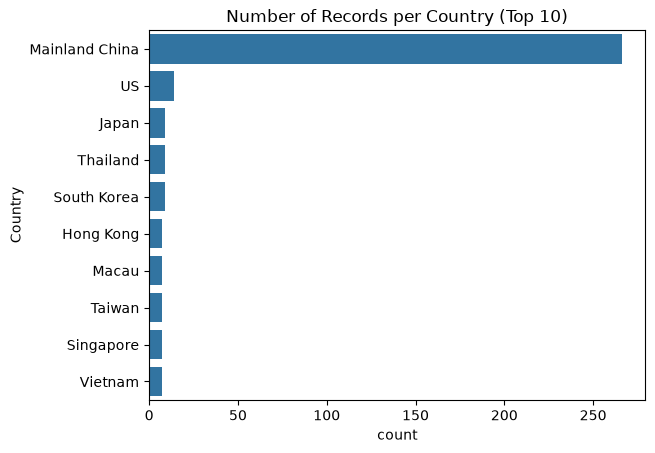

In [10]:
top_countries = df['Country'].value_counts().head(10).index
sns.countplot(data=df[df['Country'].isin(top_countries)], y='Country', order=top_countries)
plt.title('Number of Records per Country (Top 10)')
plt.show()

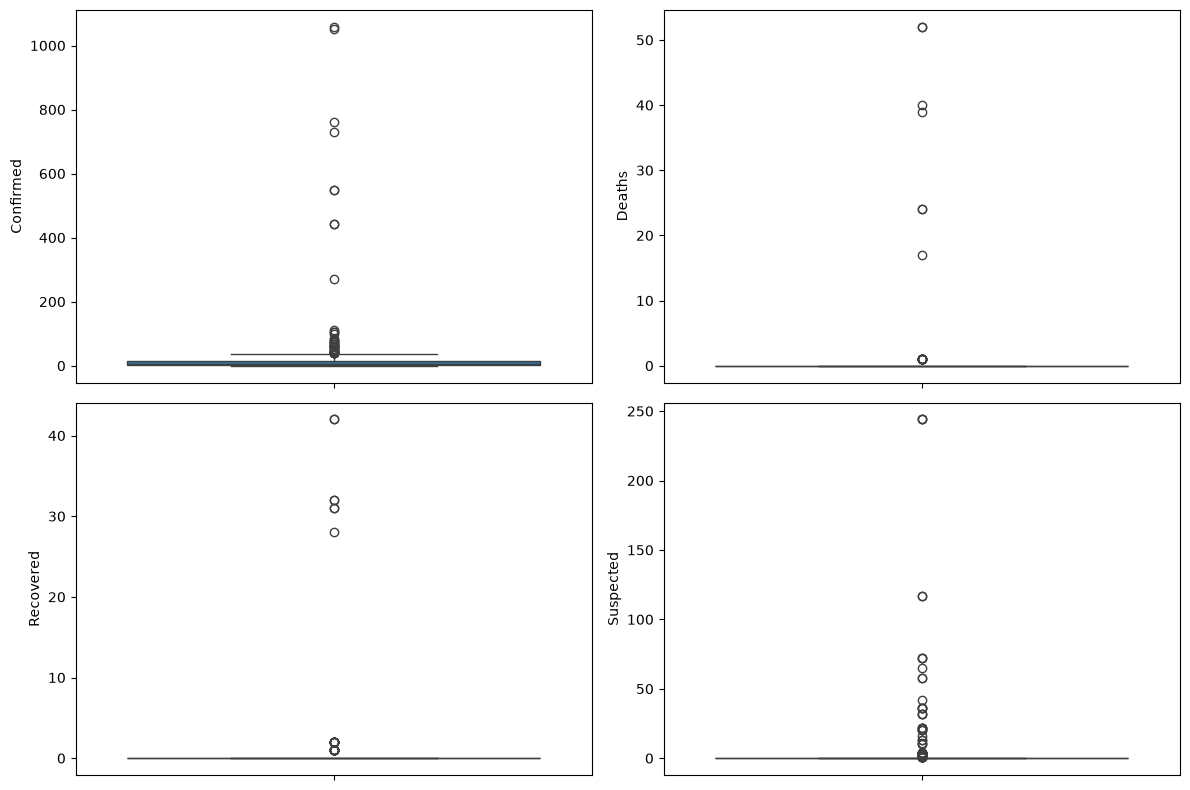

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.boxplot(y=df['Confirmed'], ax=axes[0,0])
sns.boxplot(y=df['Deaths'], ax=axes[0,1])
sns.boxplot(y=df['Recovered'], ax=axes[1,0])
sns.boxplot(y=df['Suspected'], ax=axes[1,1])
plt.tight_layout()
plt.show()

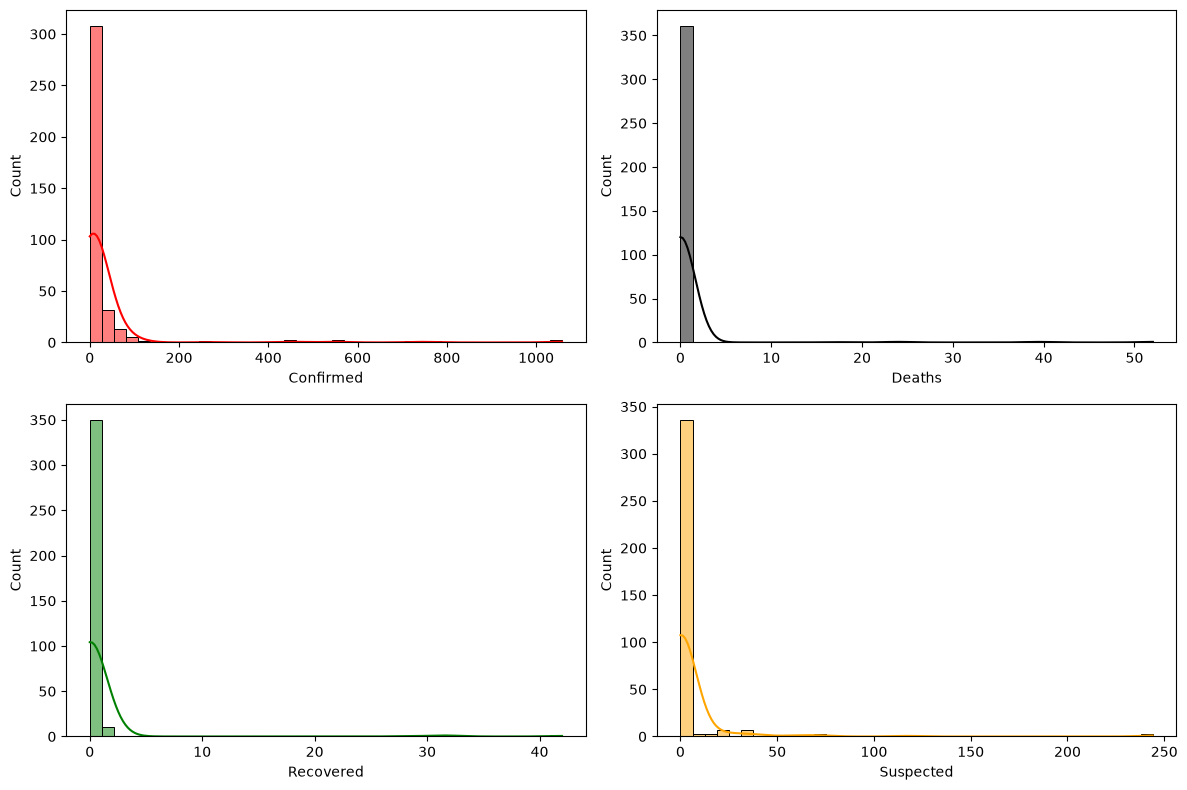

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.histplot(df['Confirmed'], kde=True, ax=axes[0,0], color='red')
sns.histplot(df['Deaths'], kde=True, ax=axes[0,1], color='black')
sns.histplot(df['Recovered'], kde=True, ax=axes[1,0], color='green')
sns.histplot(df['Suspected'], kde=True, ax=axes[1,1], color='orange')
plt.tight_layout()
plt.show()

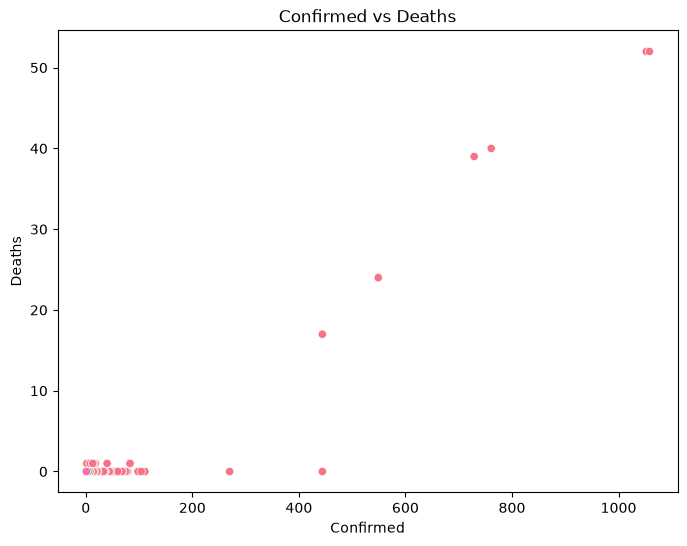

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Confirmed', y='Deaths', hue='Country', legend=False)
plt.title('Confirmed vs Deaths')
plt.show()

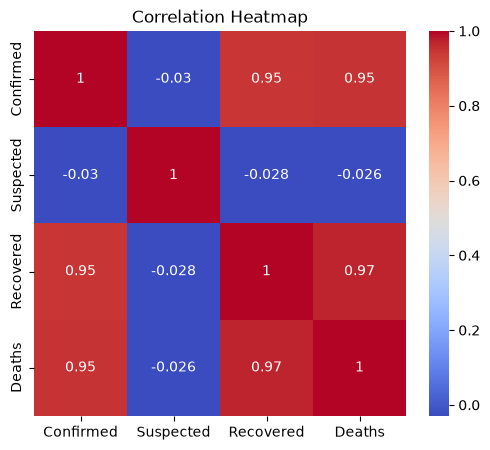

In [14]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['Confirmed','Suspected','Recovered','Deaths']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()